### Configuration, inputs & outputs

In [1]:
from pipeline_utils import make_case1_paths
import pandas as pd
import numpy as np

# Configure paths
paths = make_case1_paths()

PROJECT_DIR = paths["project"]
RAW_DIR = paths["raw_uhn"]
PROC_DIR = paths["proc"]
RESULTS_DIR = paths["results"]

print(f"Project directory: {PROJECT_DIR}")
print(f"Raw data directory: {RAW_DIR}")
print(f"Processed data directory: {PROC_DIR}")
print(f"Results directory: {RESULTS_DIR}")

# Input files
doubling_time_file = PROC_DIR / "model_doubling_times_lung.csv"
rna_file = RAW_DIR / "uhn_lung" / "RNASeq_matrix.csv"
gene_info_file = RAW_DIR / "uhn_lung" / "RNASeq_gene_annotation.csv"

dt_df = pd.read_csv(
    doubling_time_file,
    usecols=["modelID", "doubling_time_days"],
    index_col="modelID"
)

rna_df = pd.read_csv(rna_file,index_col=0)

gene_info_df = pd.read_csv(
    gene_info_file
)

print(f"Doubling-time file: {doubling_time_file}")
print(f"RNA file: {rna_file}")
print(f"Gene-info file: {gene_info_file}")

# Output files
merged_table = PROC_DIR / "rna_doubling_time_merged_lung.csv"
plot_dt = RESULTS_DIR / "figure2c_DT_lung.png"
integration_qc_table = PROC_DIR / "rna_doubling_time_integration_qc_lung.csv"

Project directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study
Raw data directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/0_datasets
Processed data directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate
Results directory: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/1_doublingRate
Doubling-time file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/model_doubling_times_lung.csv
RNA file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/0_datasets/uhn_lung/RNASeq_matrix.csv
Gene-info file: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/0_datasets/uhn_lung/RNASeq_gene_annotation.csv


/Users/guanqiaofeng/Library/Python/3.9/lib/python/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
rna_df

,PHLC110,PHLC111,PHLC119,PHLC12,PHLC132,PHLC137,PHLC148,PHLC153,PHLC164,PHLC169,...,PHLC235,PHLC267,PHLC274,PHLC299,PHLC321,PHLC402,PHLC410,PHLC655,PHLC77,PHLC82
A1BG,8.386678,8.078279,8.272438,7.886399,7.858328,7.871079,7.758086,8.194646,8.347982,8.146215,...,8.308865,7.852201,7.756390,7.824646,7.907831,7.857810,8.196621,8.005396,7.826525,7.929869
A2M,9.540696,10.819281,6.334139,7.944336,8.460975,11.080276,9.193702,9.562806,7.810539,7.857059,...,7.973499,11.348828,9.942006,12.202661,8.001325,9.233746,9.478483,7.820199,7.111889,8.037968
NAT1,9.729896,10.257485,9.803284,8.711546,8.163609,9.559824,9.688259,10.489846,9.808072,9.620173,...,9.062771,8.971286,8.556707,7.976060,9.148387,10.219367,9.577349,8.723370,9.129867,9.550650
NAT2,7.939010,8.520696,8.984858,7.501401,8.220549,7.829832,7.942452,7.960335,7.890332,7.615294,...,7.580005,7.853061,7.834455,7.759809,7.701758,7.975070,8.035362,8.649938,7.647101,7.881848
SERPINA3,8.919599,12.963661,10.255870,12.548033,13.688864,12.635293,15.005001,8.716438,11.457946,13.464361,...,8.897605,9.333778,8.681367,14.588876,9.669041,11.219758,11.022664,8.261279,10.080218,11.960201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MIR548F4,7.513489,7.610173,7.561622,7.701398,7.557118,7.574478,7.519940,7.577423,7.664666,7.547398,...,7.674908,7.470304,7.517691,7.592347,7.655426,7.539395,7.705243,7.634146,7.610726,7.474375
MIR548J,7.914105,7.752203,7.668683,7.807174,8.230777,8.028467,7.858217,7.644298,7.933829,7.903759,...,8.488680,7.881475,7.917041,7.870532,7.968182,7.721385,7.907716,7.827526,7.825777,7.687319
MIR548E,7.586798,7.645214,7.597759,7.869158,7.421109,7.711032,7.672933,7.510274,7.757174,7.534682,...,7.682155,7.620782,7.490863,7.531142,7.662733,7.518494,7.606444,7.752602,7.537695,7.504317
MIR449C,7.648054,7.467596,7.853942,8.117343,8.270993,7.643625,7.859229,7.822652,7.700153,7.501213,...,7.621181,7.560762,7.606670,7.670716,7.706267,7.644698,7.616923,7.574433,7.867110,7.721193


### Filter RNA-seq data and Merge with doubling time data

- restrict to protein-coding genes
- log2 transformation
- remove zero-variance genes
- merge RNA with doubling time

In [3]:
protein_coding_genes = set(gene_info_df.loc[gene_info_df["gene_biotype"] == "protein_coding", "hgnc_symbol"])

# Samples as rows, genes as columns
rna_df = rna_df.T

if rna_df.columns.duplicated().any():
    rna_df = rna_df.T.groupby(level=0).mean().T

rna_df = rna_df.loc[:, rna_df.columns.isin(protein_coding_genes)]

# Restrict to samples that will actually enter the analysis
common_models = rna_df.index.intersection(dt_df.index)
rna_model_df = rna_df.loc[common_models].copy()

# Low-expression filter on the original TPM/FPKM scale
min_expression = 1.0
min_fraction = 0.20
min_samples = max(3, int(np.ceil(min_fraction * len(rna_model_df))))

expressed_genes = (
    (rna_model_df >= min_expression).sum(axis=0) >= min_samples
)

rna_model_df = rna_model_df.loc[:, expressed_genes]

print(f"Minimum required samples: {min_samples}")
print(f"Genes retained after expression filter: {rna_model_df.shape[1]}")

# Log transformation
rna_log_df = np.log2(rna_model_df + 1)

# Protect against constants and floating-point-level variation
rna_log_df = rna_log_df.loc[
    :, rna_log_df.var(axis=0, ddof=0) > 1e-8
]

merged_df = rna_log_df.join(dt_df, how="inner")

merged_df.to_csv(merged_table)
print(f"rna and doubling time merged table saved: {merged_table}")

rna_only_models = sorted(set(rna_log_df.index) - set(dt_df.index))
dt_only_models = sorted(set(dt_df.index) - set(rna_log_df.index))

print(f"Models in DT list: {dt_df.shape[0]}")
print(f"Models in final RNA + DT matrix: {merged_df.shape[0]}")
print(f"Protein-coding genes after variance filter: {rna_log_df.shape[1]}")
print(f"RNA models without DT: {len(rna_only_models)}")
print(f"DT models without RNA: {len(dt_only_models)}")
print(f"Final matrix shape: {merged_df.shape}")

Minimum required samples: 6
Genes retained after expression filter: 17493


rna and doubling time merged table saved: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/rna_doubling_time_merged_lung.csv
Models in DT list: 36
Models in final RNA + DT matrix: 27
Protein-coding genes after variance filter: 17493
RNA models without DT: 0
DT models without RNA: 9
Final matrix shape: (27, 17494)


### Visualize doubling-time distribution for RNA-seq-matched PDX models (Figure 2c)

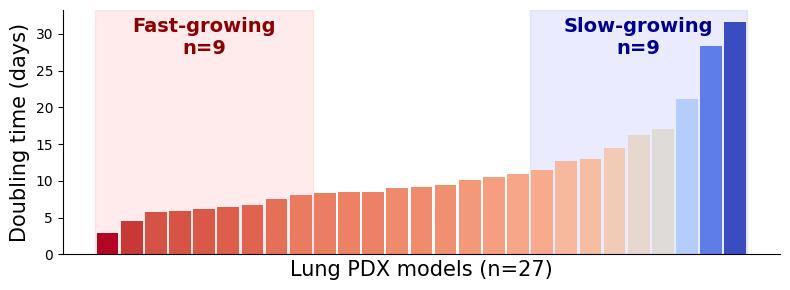

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

plot_df = (
    merged_df[["doubling_time_days"]]
    .copy()
    .sort_values("doubling_time_days")
    .reset_index(drop=True)
)

n_models = len(plot_df)

low_cutoff = plot_df["doubling_time_days"].quantile(0.33)
high_cutoff = plot_df["doubling_time_days"].quantile(0.67)

fast_mask = plot_df["doubling_time_days"] <= low_cutoff
slow_mask = plot_df["doubling_time_days"] >= high_cutoff

norm = mcolors.Normalize(
    vmin=plot_df["doubling_time_days"].min(),
    vmax=plot_df["doubling_time_days"].max(),
)
cmap = plt.get_cmap("coolwarm_r")
bar_colors = [cmap(norm(v)) for v in plot_df["doubling_time_days"]]

fig, ax = plt.subplots(figsize=(8, 3))

ax.bar(
    x=np.arange(n_models),
    height=plot_df["doubling_time_days"],
    color=bar_colors,
    width=0.9,
)

fast_idx = np.where(fast_mask)[0]
slow_idx = np.where(slow_mask)[0]

ax.axvspan(fast_idx.min() - 0.5, fast_idx.max() + 0.5, color="red", alpha=0.08, zorder=0)
ax.axvspan(slow_idx.min() - 0.5, slow_idx.max() + 0.5, color="blue", alpha=0.08, zorder=0)

ax.text(
    fast_idx.mean(),
    ax.get_ylim()[1] * 0.82,
    f"Fast-growing\nn={fast_mask.sum()}",
    color="darkred",
    weight="bold",
    ha="center",
    fontsize=14,
)

ax.text(
    slow_idx.mean(),
    ax.get_ylim()[1] * 0.82,
    f"Slow-growing\nn={slow_mask.sum()}",
    color="darkblue",
    weight="bold",
    ha="center",
    fontsize=14,
)

ax.set_xticks([])
ax.set_ylabel("Doubling time (days)", fontsize=15)
ax.set_xlabel(f"Lung PDX models (n={n_models})", fontsize=15)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig(plot_dt, dpi=300, bbox_inches="tight")
plt.show()

### QC summary for merged dataset

In [5]:
integration_qc = pd.Series({
    "rna_models_before_merge": rna_df.shape[0],
    "dt_models": dt_df.shape[0],
    "merged_models": merged_df.shape[0],
    "protein_coding_genes": rna_log_df.shape[1],
    "rna_models_without_dt": len(rna_only_models),
    "dt_models_without_rna": len(dt_only_models),
})
integration_qc.to_csv(integration_qc_table, header=["value"])

print(f"savevd integration qc table to {integration_qc_table}")
print(integration_qc)

savevd integration qc table to /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/data/procdata/1_doublingRate/rna_doubling_time_integration_qc_lung.csv
rna_models_before_merge       30
dt_models                     36
merged_models                 27
protein_coding_genes       17493
rna_models_without_dt          0
dt_models_without_rna          9
dtype: int64
